In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
path = r"../../data/Student_Performance.csv"
df = pd.read_csv(path)
df


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(127)

In [12]:
df.shape

(10000, 6)

In [13]:
df.drop_duplicates(inplace=True)

In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Extracurricular Activities']  = encoder.fit_transform(df['Extracurricular Activities'])

In [16]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [17]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [25]:
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = regressor.predict(X_test)

In [33]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Linear Regression Results ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.32
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


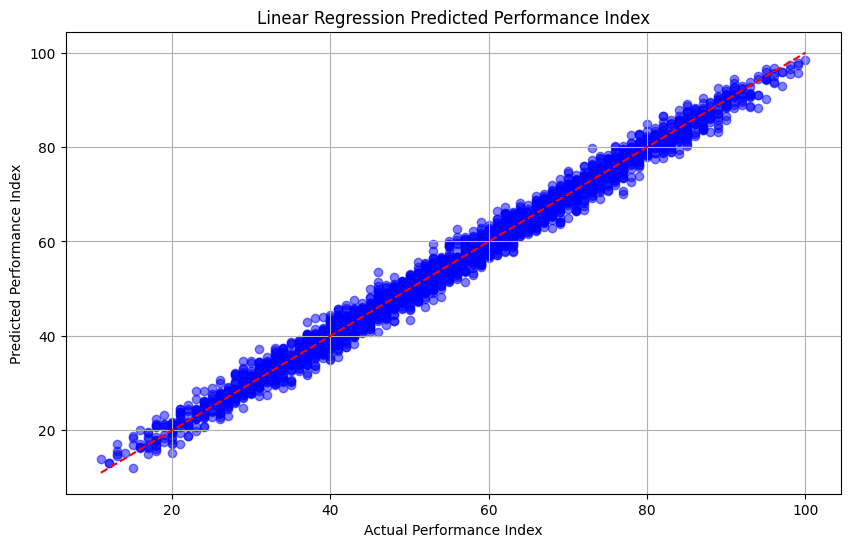

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Linear Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [38]:
poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_poly_pred = poly_regressor.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_poly_pred)
mse_poly = mean_squared_error(y_test, y_poly_pred)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_poly_pred)

print("--- Polynomial Regression Results (degree=2) ---")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")

--- Polynomial Regression Results (degree=2) ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.32
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


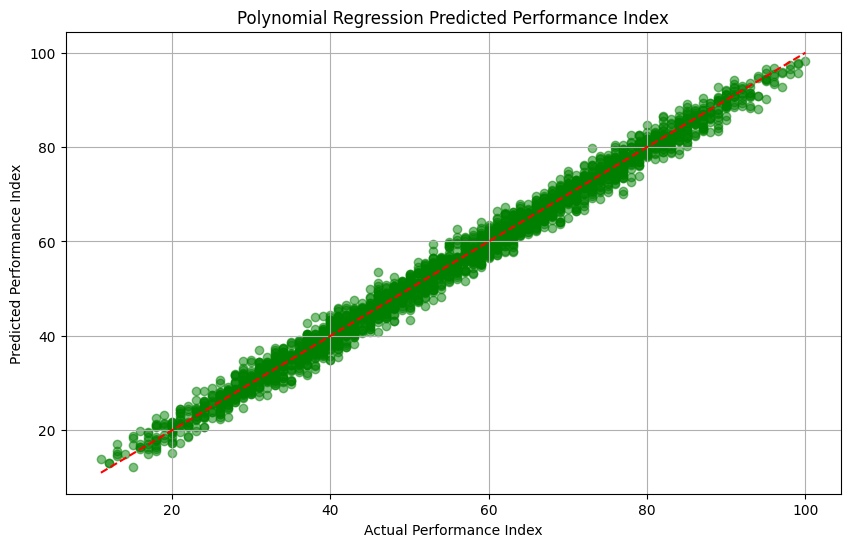

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_poly_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Polynomial Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [41]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train, y_train)

y_lasso_pred = lasso.predict(X_test)

In [42]:
mae_lasso = mean_absolute_error(y_test, y_lasso_pred)
mse_lasso = mean_squared_error(y_test, y_lasso_pred)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_lasso_pred)

print("--- Lasso Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")

--- Lasso Regression Results ---
Mean Absolute Error (MAE): 1.81
Mean Squared Error (MSE): 5.16
Root Mean Squared Error (RMSE): 2.27
R-squared (R2): 0.99


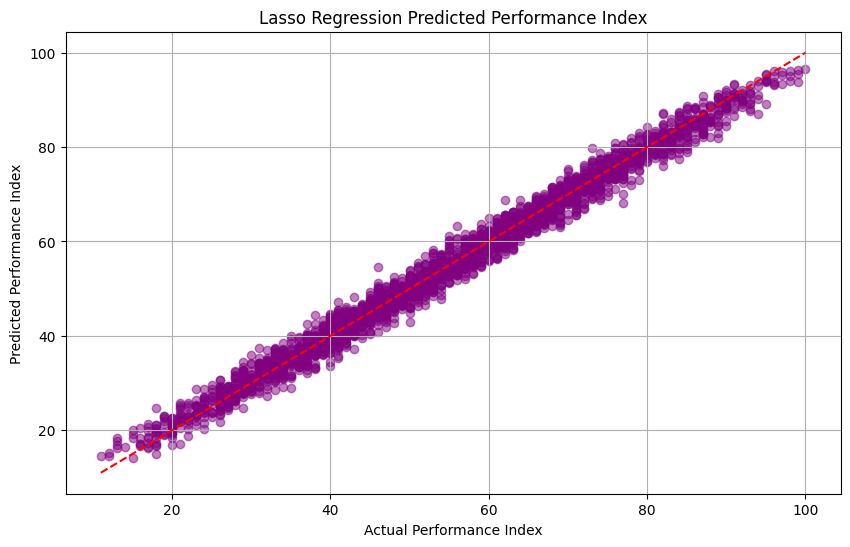

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_lasso_pred, color='purple', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Lasso Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [44]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

y_ridge_pred = ridge.predict(X_test)

In [45]:
mae_ridge = mean_absolute_error(y_test, y_ridge_pred)
mse_ridge = mean_squared_error(y_test, y_ridge_pred)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_ridge_pred)

print("--- Ridge Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")

--- Ridge Regression Results ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.32
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


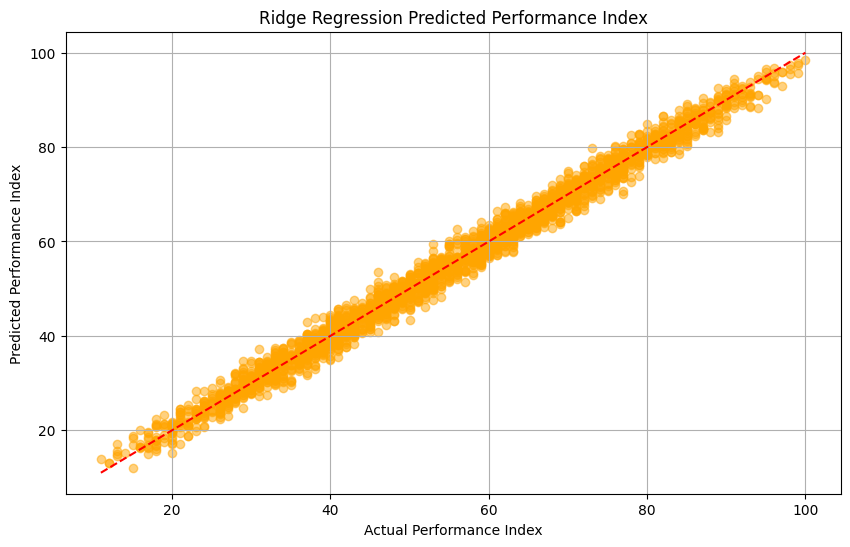

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_ridge_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Ridge Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [47]:
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

y_dt_pred = dt_regressor.predict(X_test)

In [48]:
mae_dt = mean_absolute_error(y_test, y_dt_pred)
mse_dt = mean_squared_error(y_test, y_dt_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_dt_pred)

print("--- Decision Tree Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")

--- Decision Tree Regression Results ---
Mean Absolute Error (MAE): 2.41
Mean Squared Error (MSE): 9.23
Root Mean Squared Error (RMSE): 3.04
R-squared (R2): 0.98


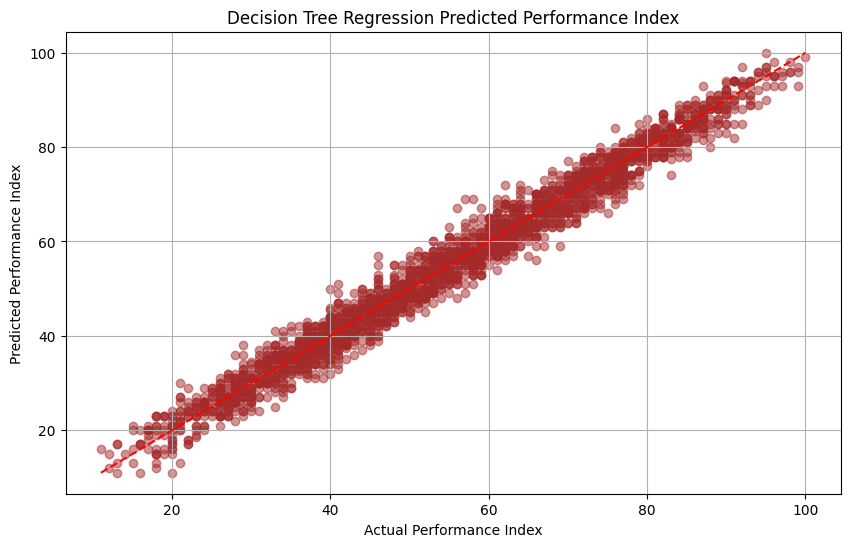

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_dt_pred, color='brown', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Decision Tree Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

y_rf_pred = rf_regressor.predict(X_test)

In [51]:
mae_rf = mean_absolute_error(y_test, y_rf_pred)
mse_rf = mean_squared_error(y_test, y_rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_rf_pred)

print("--- Random Forest Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

--- Random Forest Regression Results ---
Mean Absolute Error (MAE): 1.92
Mean Squared Error (MSE): 5.73
Root Mean Squared Error (RMSE): 2.39
R-squared (R2): 0.98


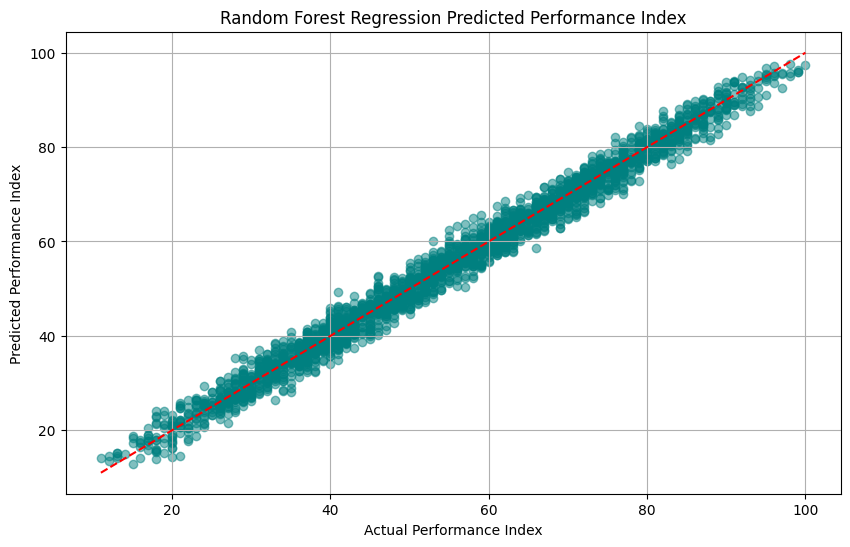

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_rf_pred, color='teal', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Random Forest Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()

In [53]:
from sklearn.svm import SVR

svm_regressor = SVR(kernel='rbf')
svm_regressor.fit(X_train, y_train)

y_svm_pred = svm_regressor.predict(X_test)

In [54]:
mae_svm = mean_absolute_error(y_test, y_svm_pred)
mse_svm = mean_squared_error(y_test, y_svm_pred)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_svm_pred)

print("--- SVM Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_svm:.2f}")
print(f"Mean Squared Error (MSE): {mse_svm:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svm:.2f}")
print(f"R-squared (R2): {r2_svm:.2f}")

--- SVM Regression Results ---
Mean Absolute Error (MAE): 1.91
Mean Squared Error (MSE): 5.72
Root Mean Squared Error (RMSE): 2.39
R-squared (R2): 0.98


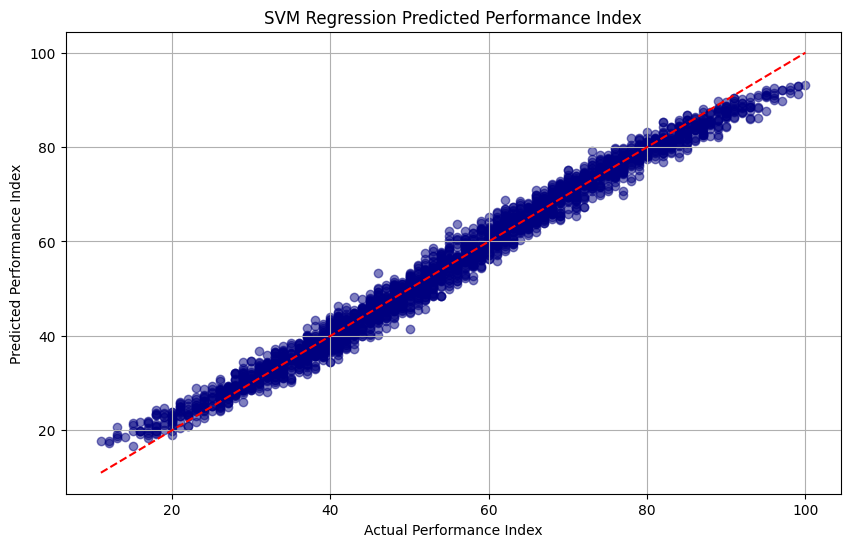

In [55]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_svm_pred, color='navy', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('SVM Regression Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid()
plt.show()